# Automatska klasifikacija IT support tiketa pomoću neuronskih mreža

Ovaj projekat prikazuje kompletan tok izrade sistema koji na osnovu opisa IT support tiketa automatski predviđa njegovu kategoriju. U praksi ovakav sistem može da ubrza rad help desk tima, da automatski usmerava zahteve ka odgovarajućem timu i da smanji vreme ručne obrade tiketa.

U notebook-u će biti obrađeni sledeći koraci:
- preuzimanje dataseta direktno sa Kaggle-a preko API-ja,
- učitavanje i analiza podataka,
- čišćenje teksta i priprema labela,
- baseline model sa TF-IDF reprezentacijom,
- neuronska mreža za tekstualnu klasifikaciju,
- eksperimenti sa različitim hiperparametrima,
- evaluacija metrikama `accuracy`, `precision`, `recall` i `F1-score`,
- čuvanje najboljeg modela i predikcija novih tiketa.

Krajnji rezultat projekta je model koji direktno prima sirov tekst tiketa i vraća predviđenu kategoriju zajedno sa pouzdanošću predikcije.


## 1. Uvod

Klasifikacija IT support tiketa predstavlja zadatak vi?eklasne klasifikacije teksta. U ovom projektu kori??en je Kaggle dataset **IT Service Ticket Classification Dataset** (`adisongoh/it-service-ticket-classification-dataset`), a nakon preuzimanja koristi se CSV fajl `all_tickets_processed_improved_v3.csv`.

Dataset sadr?i **47.837** tiketa i **8 kategorija**: `Access`, `Administrative rights`, `HR Support`, `Hardware`, `Internal Project`, `Miscellaneous`, `Purchase` i `Storage`.

Za evaluaciju koristimo:
- `accuracy` kao op?tu ta?nost klasifikacije,
- `precision macro` da proverimo koliko su predikcije po klasama precizne,
- `recall macro` da proverimo koliko dobro model pronalazi primere svake klase,
- `F1 macro` kao glavnu metriku za pore?enje modela, jer dataset nije potpuno balansiran.

Cilj projekta je da napravimo model koji prima tekst tiketa i vra?a najverovatniju kategoriju zajedno sa procenom pouzdanosti predikcije.


In [37]:
import os
import re
import json
import random
import shutil
import subprocess
import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import sklearn

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Conv1D,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PLOTS_DIR = PROJECT_ROOT / "plots"

for folder in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR, PLOTS_DIR]:
    folder.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


## 2. Import biblioteka i podešavanja

U ovoj sekciji učitavamo biblioteke potrebne za rad sa podacima, baseline model, neuronske mreže i vizualizacije. Takođe postavljamo `seed` vrednost radi ponovljivosti rezultata i kreiramo foldere za modele, izlaze i grafikone.


In [38]:
print(f"Python verzija: {platform.python_version()}")
print(f"TensorFlow verzija: {tf.__version__}")
print(f"pandas verzija: {pd.__version__}")
print(f"scikit-learn verzija: {sklearn.__version__}")
print(f"Radni direktorijum: {PROJECT_ROOT.resolve()}")


Python verzija: 3.12.13
TensorFlow verzija: 2.20.0
pandas verzija: 2.2.2
scikit-learn verzija: 1.6.1
Radni direktorijum: /content


## 3. Kaggle API pode?avanje i preuzimanje dataseta

Dataset se preuzima direktno sa Kaggle-a tokom izvr?avanja notebook-a, pa se fajlovi pojavljuju u folderu `data/` samo u okviru aktivnog runtime-a. Nakon resetovanja Colab runtime-a, fajlove je potrebno ponovo preuzeti.

U ovoj verziji notebook-a Kaggle kredencijali su upisani direktno u kod, a zatim se pre poziva Kaggle CLI executable-a postavljaju kroz environment promenljive.

**Bezbednosna napomena:** ovaj notebook sadr?i privatni Kaggle API token direktno u kodu. Ne treba ga deliti javno niti commitovati na GitHub.


In [ ]:
import importlib.util

KAGGLE_USERNAME = 'mihajlodunjic'
KAGGLE_KEY = ''
KAGGLE_DATASET = "adisongoh/it-service-ticket-classification-dataset"
CSV_FILENAME = "all_tickets_processed_improved_v3.csv"


def ensure_kaggle_installed():
    if importlib.util.find_spec("kaggle") is None:
        print("Instaliram Kaggle biblioteku...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
        print("Kaggle biblioteka je uspesno instalirana.")
    else:
        print("Kaggle biblioteka je vec dostupna.")


In [40]:
def configure_kaggle_auth():
    if not KAGGLE_USERNAME or not KAGGLE_KEY:
        raise ValueError("KAGGLE_USERNAME i KAGGLE_KEY moraju biti postavljeni u notebook-u.")

    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
    os.environ["KAGGLE_KEY"] = KAGGLE_KEY

    return {
        "username_set": bool(os.environ.get("KAGGLE_USERNAME")),
        "key_set": bool(os.environ.get("KAGGLE_KEY")),
    }


def get_kaggle_command():
    kaggle_command = shutil.which("kaggle")
    if kaggle_command:
        return kaggle_command

    python_dir = Path(sys.executable).resolve().parent
    candidate_paths = [
        python_dir / "kaggle",
        python_dir / "Scripts" / "kaggle.exe",
        Path("/usr/local/bin/kaggle"),
        Path("/usr/bin/kaggle"),
    ]

    for candidate in candidate_paths:
        if candidate.exists():
            return str(candidate)

    raise FileNotFoundError(
        "Kaggle CLI executable nije pronadjen. Proverite da li je paket instaliran i da li je komanda 'kaggle' dostupna u runtime-u."
    )


def download_kaggle_dataset(dataset_slug, data_dir):
    if not dataset_slug:
        raise ValueError("KAGGLE_DATASET mora biti postavljen.")

    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    kaggle_command = get_kaggle_command()

    command = [
        kaggle_command,
        "datasets",
        "download",
        "-d",
        dataset_slug,
        "-p",
        str(data_dir),
        "--unzip",
        "--force",
    ]

    try:
        completed = subprocess.run(
            command,
            check=True,
            capture_output=True,
            text=True,
            env=os.environ.copy(),
        )
        stdout = completed.stdout.strip()
        stderr = completed.stderr.strip()
        if stdout:
            print(stdout)
        if stderr:
            print(stderr)
    except FileNotFoundError as exc:
        raise RuntimeError(
            "Kaggle CLI executable nije dostupan. Proverite da li je biblioteka instalirana i restartujte runtime ako je potrebno."
        ) from exc
    except subprocess.CalledProcessError as exc:
        error_message = exc.stderr.strip() or exc.stdout.strip() or str(exc)
        raise RuntimeError(
            "Preuzimanje dataseta nije uspelo. Proverite da li su KAGGLE_USERNAME i KAGGLE_KEY ispravni i da li API token ima pristup datasetu. "
            f"Kaggle API poruka: {error_message}"
        ) from exc

    return data_dir


In [41]:
ensure_kaggle_installed()
kaggle_auth_status = configure_kaggle_auth()
print(f"Kaggle API je podesen. Username set: {kaggle_auth_status['username_set']}, key set: {kaggle_auth_status['key_set']}")

download_kaggle_dataset(KAGGLE_DATASET, DATA_DIR)
print(f"Dataset je preuzet u direktorijum: {DATA_DIR.resolve()}")


Kaggle biblioteka je vec dostupna.
Kaggle API je podesen. Username set: True, key set: True
Dataset URL: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset
License(s): CC0-1.0
0%|          | 0.00/3.45M [00:00<?, ?B/s]
100%|██████████| 3.45M/3.45M [00:00<00:00, 234MB/s]
Dataset je preuzet u direktorijum: /content/data


## 4. U?itavanje dataseta

Posle preuzimanja koristi se konkretan CSV fajl `data/all_tickets_processed_improved_v3.csv`. Taj fajl sadr?i dve kolone i predstavlja ve? pripremljenu verziju dataseta za klasifikaciju IT support tiketa.


In [42]:
CSV_PATH = DATA_DIR / CSV_FILENAME
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"O?ekivani CSV fajl nije prona?en: {CSV_PATH}. Proverite da li je Kaggle download uspe?no zavr?en."
    )

try:
    df = pd.read_csv(CSV_PATH, low_memory=False)
except UnicodeDecodeError:
    df = pd.read_csv(CSV_PATH, encoding="latin-1", low_memory=False)

print(f"U?itani CSV fajl: {CSV_PATH}")
display(df.head())
print(f"Broj redova i kolona: {df.shape}")
print(f"Nazivi kolona: {df.columns.tolist()}")
print()
print("Tipovi podataka po koloni:")
display(df.dtypes.astype(str).rename("dtype").to_frame())
print("Broj nedostaju?ih vrednosti po koloni:")
display(df.isna().sum().rename("missing_values").to_frame())
print("Sa?etak preko df.info():")
df.info()


U?itani CSV fajl: data/all_tickets_processed_improved_v3.csv


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Broj redova i kolona: (47837, 2)
Nazivi kolona: ['Document', 'Topic_group']

Tipovi podataka po koloni:


,dtype
Document,object
Topic_group,object


Broj nedostaju?ih vrednosti po koloni:


,missing_values
Document,0
Topic_group,0


Sa?etak preko df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


## 5. Izbor tekstualne i ciljne kolone

U ovom datasetu kolona `Document` sadr?i tekst tiketa, dok kolona `Topic_group` predstavlja ciljnu kategoriju. Zbog toga se ove dve kolone direktno koriste u finalnom toku notebook-a.


In [43]:
TEXT_COLUMN = "Document"
LABEL_COLUMN = "Topic_group"

print(f"Kolona za tekst tiketa: {TEXT_COLUMN}")
print(f"Kolona za kategoriju: {LABEL_COLUMN}")

data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ["text", "category"]
display(data.head())


Kolona za tekst tiketa: Document
Kolona za kategoriju: Topic_group


,text,category
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


## 6. Pregled i analiza podataka

Pre treniranja modela proveravamo osnovne karakteristike dataseta:
- ukupan broj primera,
- broj kategorija,
- raspodelu klasa,
- du?inu tekstova.

Na osnovu distribucije vidi se da su klase `Hardware` i `HR Support` najzastupljenije, dok su `Administrative rights` i `Internal Project` manje zastupljene. Zbog toga je `F1 macro` va?na metrika u ovom projektu.


Broj primera: 47837
Broj kategorija: 8


,broj_primera,procenat
category,,
Hardware,13617,28.47
HR Support,10915,22.82
Access,7125,14.89
Miscellaneous,7060,14.76
Storage,2777,5.81
Purchase,2464,5.15
Internal Project,2119,4.43
Administrative rights,1760,3.68


Prose?na du?ina teksta: 43.60 re?i
Minimalna du?ina teksta: 2 re?i
Maksimalna du?ina teksta: 981 re?i


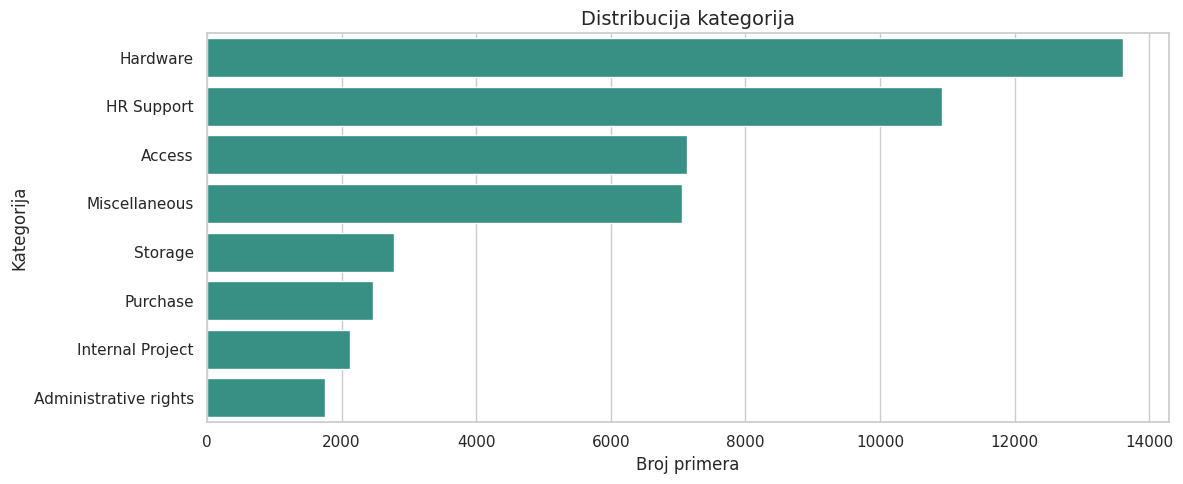

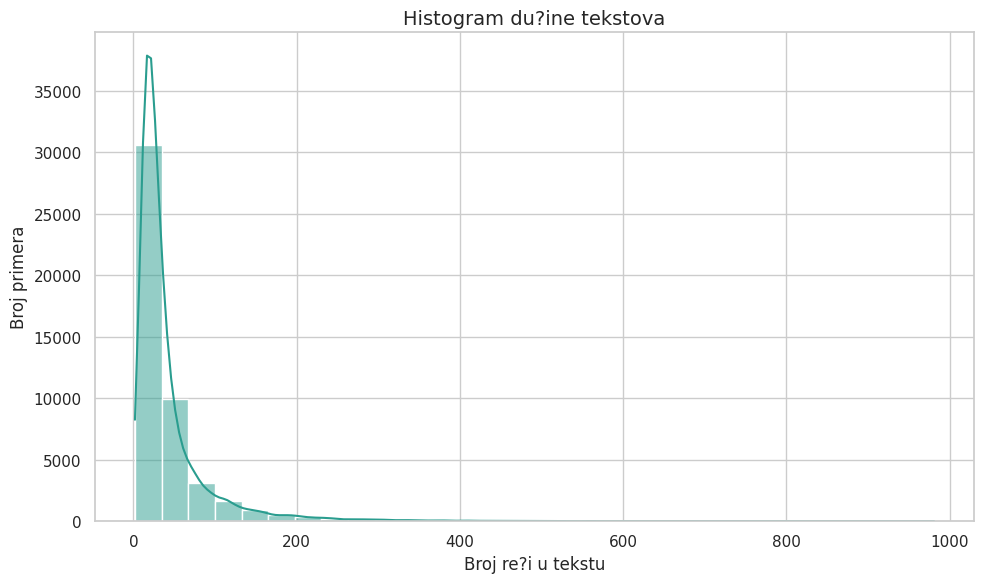

In [44]:
def plot_class_distribution(data, save_path=None):
    class_counts = data["category"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(12, max(5, len(class_counts) * 0.45)))
    sns.barplot(x=class_counts.values, y=class_counts.index, color="#2a9d8f")
    plt.title("Distribucija kategorija")
    plt.xlabel("Broj primera")
    plt.ylabel("Kategorija")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_text_lengths(data, text_column="text", save_path=None):
    text_lengths = data[text_column].astype(str).str.split().map(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(text_lengths, bins=30, kde=True, color="#2a9d8f")
    plt.title("Histogram du?ine tekstova")
    plt.xlabel("Broj re?i u tekstu")
    plt.ylabel("Broj primera")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


print(f"Broj primera: {len(data)}")
print(f"Broj kategorija: {data['category'].nunique()}")

class_counts = data["category"].value_counts()
class_percentages = (class_counts / len(data) * 100).round(2)
class_summary = pd.DataFrame(
    {
        "broj_primera": class_counts,
        "procenat": class_percentages,
    }
)
display(class_summary)

text_lengths = data["text"].astype(str).str.split().map(len)
print(f"Prose?na du?ina teksta: {text_lengths.mean():.2f} re?i")
print(f"Minimalna du?ina teksta: {text_lengths.min()} re?i")
print(f"Maksimalna du?ina teksta: {text_lengths.max()} re?i")

plot_class_distribution(data, PLOTS_DIR / "class_distribution.png")
plot_text_lengths(data, "text", PLOTS_DIR / "text_lengths.png")


## 7. Čišćenje podataka

Tekstualni podaci često sadrže nepotrebne razmake, URL-ove, email adrese i specijalne karaktere. Cilj čišćenja nije da uklonimo svaku informaciju, već da zadržimo ključne IT pojmove kao što su `password`, `printer`, `vpn`, `server`, `network` i slični izrazi.


In [45]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


initial_rows = len(data)

data["text"] = data["text"].fillna("").astype(str).str.strip()
data["category"] = data["category"].fillna("").astype(str).str.strip()

data = data[(data["text"] != "") & (data["category"] != "")].copy()
rows_after_missing = len(data)

data["clean_text"] = data["text"].apply(clean_text)
data = data[data["clean_text"].str.len() > 0].copy()

data = data.drop_duplicates(subset=["clean_text", "category"]).copy()
rows_after_duplicates = len(data)

print(f"Broj redova pre čišćenja: {initial_rows}")
print(f"Broj redova posle uklanjanja praznih vrednosti: {rows_after_missing}")
print(f"Broj redova posle uklanjanja duplikata: {rows_after_duplicates}")

display(data[["text", "clean_text", "category"]].head())


Broj redova pre čišćenja: 47837
Broj redova posle uklanjanja praznih vrednosti: 47837
Broj redova posle uklanjanja duplikata: 47837


,text,clean_text,category
0,connection with icon icon dear please setup ic...,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,mail verification warning hi has got attached ...,Miscellaneous


## 8. Pretvaranje kategorija u numerički oblik

Model ne može direktno da radi sa tekstualnim nazivima kategorija, pa svaku kategoriju pretvaramo u numeričku labelu pomoću `LabelEncoder` klase. Mapiranje čuvamo u JSON fajl da bismo kasnije mogli da prevedemo numerički izlaz modela nazad u naziv kategorije.


In [46]:
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["category"])

label_names = label_encoder.classes_.tolist()
id_to_label = {str(index): label for index, label in enumerate(label_names)}
label_to_id = {label: index for index, label in enumerate(label_names)}
label_mapping = {
    "id_to_label": id_to_label,
    "label_to_id": label_to_id,
}

with open(MODELS_DIR / "label_mapping.json", "w", encoding="utf-8") as file:
    json.dump(label_mapping, file, ensure_ascii=False, indent=2)

label_mapping_df = pd.DataFrame(
    {
        "label_id": list(range(len(label_names))),
        "category": label_names,
    }
)
display(label_mapping_df)
print(f"Mapiranje labela je sačuvano u: {MODELS_DIR / 'label_mapping.json'}")


,label_id,category
0,0,Access
1,1,Administrative rights
2,2,HR Support
3,3,Hardware
4,4,Internal Project
5,5,Miscellaneous
6,6,Purchase
7,7,Storage


Mapiranje labela je sačuvano u: models/label_mapping.json


## 9. Podela podataka

Po?to svaka od 8 klasa ima dovoljno primera, skup podataka delimo stratifikovano na:
- trening skup (`70%`),
- validacioni skup (`15%`),
- test skup (`15%`).

Na ovaj na?in raspodela kategorija ostaje prakti?no ista u svim podskupovima.


In [47]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    random_state=SEED,
    stratify=data["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Na?in podele: stratify")
print(f"Train skup: {train_df.shape}")
print(f"Validation skup: {val_df.shape}")
print(f"Test skup: {test_df.shape}")

split_distribution_counts = pd.concat(
    {
        "train": train_df["category"].value_counts(),
        "validation": val_df["category"].value_counts(),
        "test": test_df["category"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

split_distribution_percentages = (
    split_distribution_counts.div(split_distribution_counts.sum(axis=0), axis=1) * 100
).round(2)

print("Distribucija klasa po skupovima (broj primera):")
display(split_distribution_counts)
print("Distribucija klasa po skupovima (procenti):")
display(split_distribution_percentages)


Na?in podele: stratify
Train skup: (33485, 4)
Validation skup: (7176, 4)
Test skup: (7176, 4)
Distribucija klasa po skupovima (broj primera):


,train,validation,test
category,,,
Hardware,9532,2043,2042
HR Support,7640,1637,1638
Access,4987,1069,1069
Miscellaneous,4942,1059,1059
Storage,1944,417,416
Purchase,1725,369,370
Internal Project,1483,318,318
Administrative rights,1232,264,264


Distribucija klasa po skupovima (procenti):


,train,validation,test
category,,,
Hardware,28.47,28.47,28.46
HR Support,22.82,22.81,22.83
Access,14.89,14.90,14.90
Miscellaneous,14.76,14.76,14.76
Storage,5.81,5.81,5.80
Purchase,5.15,5.14,5.16
Internal Project,4.43,4.43,4.43
Administrative rights,3.68,3.68,3.68


## 10. Tokenizacija i vektorizacija

Neuronska mreža ne može direktno da obrađuje sirov tekst, pa tekst prvo pretvaramo u niz celobrojnih tokena. To radi `TextVectorization` sloj:
- tokenizacija deli tekst na reči,
- vektorizacija svakoj reči dodeljuje numerički identifikator,
- svi tekstovi se skraćuju ili dopunjuju na istu dužinu da bi model mogao da ih primi kao ulaz.

Važno je da se `TextVectorization` adaptira samo na trening skupu, kako ne bismo "procurili" informacije iz validacionog i test skupa.


In [48]:
MAX_TOKENS = 10_000
SEQUENCE_LENGTH = 100


def create_vectorizer(train_texts, max_tokens, sequence_length):
    vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize=None,
    )
    vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_texts).batch(128))
    return vectorizer


X_train = train_df["clean_text"].astype(str).values
y_train = train_df["label"].values

X_val = val_df["clean_text"].astype(str).values
y_val = val_df["label"].values

X_test = test_df["clean_text"].astype(str).values
y_test = test_df["label"].values

num_classes = len(label_names)

vectorizer = create_vectorizer(X_train, MAX_TOKENS, SEQUENCE_LENGTH)
sample_original_text = train_df.iloc[0]["text"]
sample_clean_text = train_df.iloc[0]["clean_text"]
sample_vectorized_text = vectorizer(tf.constant([sample_clean_text])).numpy()[0][:30]

print("Primer originalnog teksta:")
print(sample_original_text)
print("\nPrimer očišćenog teksta:")
print(sample_clean_text)
print("\nPrvih 30 tokena vektorizovanog teksta:")
print(sample_vectorized_text)
print(f"Veličina vokabulara: {len(vectorizer.get_vocabulary())}")


Primer originalnog teksta:
increase drive space at pc increase drive pc hello disc almost extend please kind regards engineer

Primer očišćenog teksta:
increase drive space at pc increase drive pc hello disc almost extend please kind regards engineer

Prvih 30 tokena vektorizovanog teksta:
[ 593  473  449 1617  387  593  473  387    8 4336  609  972    2   14
    5   33    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
Veličina vokabulara: 10000


## 11. Baseline model

Baseline model služi kao referentna tačka. Ako neuronska mreža ne daje bolje rezultate od jednostavnijeg pristupa, to je važan signal da arhitekturu ili pripremu podataka treba poboljšati.

Kao baseline koristimo:
- `TF-IDF` za reprezentaciju teksta,
- `LogisticRegression` kao klasični klasifikator.


Baseline - klasifikacioni izveštaj:
                       precision    recall  f1-score   support

               Access       0.91      0.85      0.88      1069
Administrative rights       0.64      0.86      0.73       264
           HR Support       0.89      0.85      0.87      1638
             Hardware       0.86      0.82      0.84      2042
     Internal Project       0.81      0.94      0.87       318
        Miscellaneous       0.79      0.86      0.82      1059
             Purchase       0.92      0.91      0.91       370
              Storage       0.85      0.91      0.88       416

             accuracy                           0.85      7176
            macro avg       0.83      0.87      0.85      7176
         weighted avg       0.86      0.85      0.85      7176



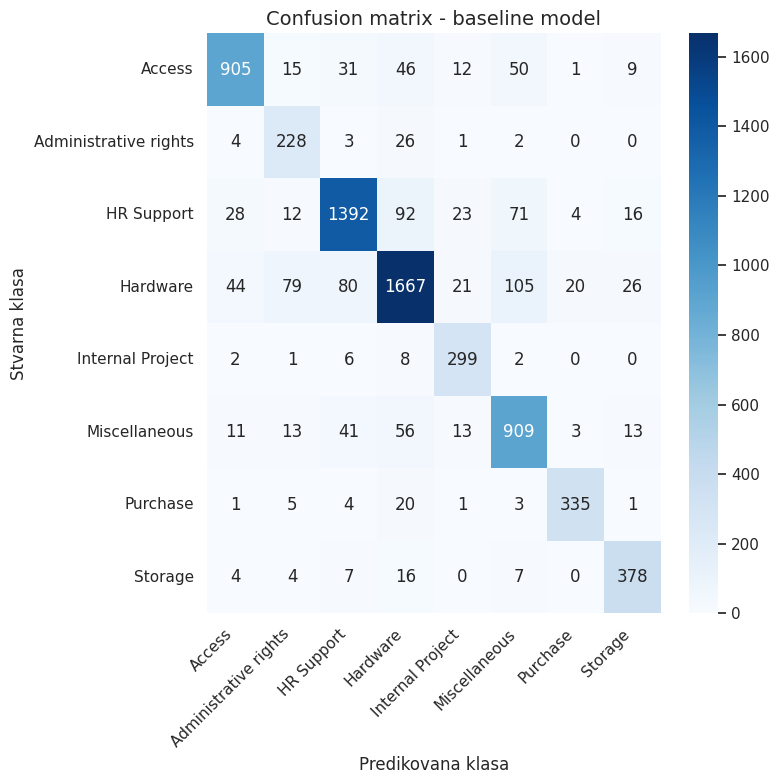

{'model': 'TF-IDF + Logistic Regression',
 'accuracy': 0.8518673355629878,
 'precision_macro': 0.8341548989297959,
 'recall_macro': 0.8736328856356064,
 'f1_macro': 0.8506078538108122}

In [49]:
def calculate_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }


def plot_confusion_matrix(y_true, y_pred, label_names, title, save_path=None):
    labels = list(range(len(label_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    figure_size = max(8, int(len(label_names) * 0.8))
    plt.figure(figsize=(figure_size, figure_size))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.title(title)
    plt.xlabel("Predikovana klasa")
    plt.ylabel("Stvarna klasa")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return cm


results = []
history_store = {}

baseline_vectorizer = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))
X_train_tfidf = baseline_vectorizer.fit_transform(X_train)
X_test_tfidf = baseline_vectorizer.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)
baseline_metrics = calculate_metrics(y_test, baseline_predictions)
baseline_result = {"model": "TF-IDF + Logistic Regression", **baseline_metrics}
results.append(baseline_result)

print("Baseline - klasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        baseline_predictions,
        labels=list(range(len(label_names))),
        target_names=label_names,
        zero_division=0,
    )
)

plot_confusion_matrix(
    y_test,
    baseline_predictions,
    label_names,
    "Confusion matrix - baseline model",
    PLOTS_DIR / "baseline_confusion_matrix.png",
)

baseline_result


## 12. Osnovni neuronski model

Osnovni neuralni model koristi sledeću ideju:
- tekst se pretvara u tokene,
- svaki token dobija svoju ugrađenu vektorsku reprezentaciju (`Embedding`),
- prosečna reprezentacija cele sekvence se prosleđuje gustim slojevima,
- izlazni sloj sa `softmax` aktivacijom vraća verovatnoće po klasama.

Ovakva arhitektura je jednostavna, dovoljno brza za Colab i pogodna za studentsko objašnjenje.


In [50]:
def build_basic_nn_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim=64,
    dense_units=64,
    dropout_rate=0.3,
):
    vocab_size = min(max_tokens, len(vectorizer.get_vocabulary()))

    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="ticket_text")
    x = vectorizer(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding")(x)
    x = GlobalAveragePooling1D(name="global_average_pooling")(x)
    x = Dense(dense_units, activation="relu", name="dense_hidden")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="classifier")(x)

    model = tf.keras.Model(inputs, outputs, name="basic_ticket_classifier")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_experiment_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim,
    dense_units,
    dropout_rate,
):
    return build_basic_nn_model(
        vectorizer=vectorizer,
        max_tokens=max_tokens,
        num_classes=num_classes,
        embedding_dim=embedding_dim,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
    )


def build_cnn_model(
    vectorizer,
    max_tokens,
    num_classes,
    embedding_dim=64,
    filters=64,
    kernel_size=5,
    dense_units=64,
    dropout_rate=0.4,
):
    vocab_size = min(max_tokens, len(vectorizer.get_vocabulary()))

    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="ticket_text")
    x = vectorizer(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding")(x)
    x = Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", name="conv1d")(x)
    x = GlobalMaxPooling1D(name="global_max_pooling")(x)
    x = Dense(dense_units, activation="relu", name="dense_hidden")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="classifier")(x)

    model = tf.keras.Model(inputs, outputs, name="cnn_ticket_classifier")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_training_history(history, title, save_path=None):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df.index + 1, history_df["accuracy"], marker="o", label="train accuracy")
    axes[0].plot(history_df.index + 1, history_df["val_accuracy"], marker="o", label="val accuracy")
    axes[0].set_title(f"{title} - accuracy")
    axes[0].set_xlabel("Epoha")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_df.index + 1, history_df["loss"], marker="o", label="train loss")
    axes[1].plot(history_df.index + 1, history_df["val_loss"], marker="o", label="val loss")
    axes[1].set_title(f"{title} - loss")
    axes[1].set_xlabel("Epoha")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return history_df


def evaluate_model(model, X_test, y_test, label_names, model_name, save_path=None):
    probabilities = model.predict(X_test, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    metrics = calculate_metrics(y_test, y_pred)

    print(f"Model: {model_name}")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=list(range(len(label_names))),
            target_names=label_names,
            zero_division=0,
        )
    )

    plot_confusion_matrix(
        y_test,
        y_pred,
        label_names,
        f"Confusion matrix - {model_name}",
        save_path=save_path,
    )

    result = {"model": model_name, **metrics}
    return result, y_pred, probabilities


def is_better_result(candidate, best_so_far):
    if best_so_far is None:
        return True
    if candidate["f1_macro"] > best_so_far["f1_macro"]:
        return True
    if np.isclose(candidate["f1_macro"], best_so_far["f1_macro"]) and candidate["accuracy"] > best_so_far["accuracy"]:
        return True
    return False


## 13. Trening osnovnog modela

Za trening koristimo:
- `EarlyStopping` da zaustavimo trening kada validacioni gubitak prestane da se poboljšava,
- `ModelCheckpoint` da sačuvamo najbolju verziju modela.

Na ovaj način trening ostaje stabilan i dobijamo model koji je dao najbolji rezultat na validacionom skupu.


Model: "basic_ticket_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ticket_text (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_6            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,680 (2.46 MB)

 Trainable params: 644,680 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5740 - loss: 1.2351 - val_accuracy: 0.7896 - val_loss: 0.6547
Epoch 2/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8185 - loss: 0.5626 - val_accuracy: 0.8386 - val_loss: 0.4926
Epoch 3/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8518 - loss: 0.4474 - val_accuracy: 0.8360 - val_loss: 0.4868
Epoch 4/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8710 - loss: 0.3893 - val_accuracy: 0.8425 - val_loss: 0.4642
Epoch 5/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8827 - loss: 0.3484 - val_accuracy: 0.8416 - val_loss: 0.4763
Epoch 6/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8903 - loss: 0.3239 - val_accuracy: 0.8475 - val_loss: 0.4726
Epoch 7/20
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8988 - loss: 0.3008 - val_accuracy: 0.8455 - val_loss: 0.4839


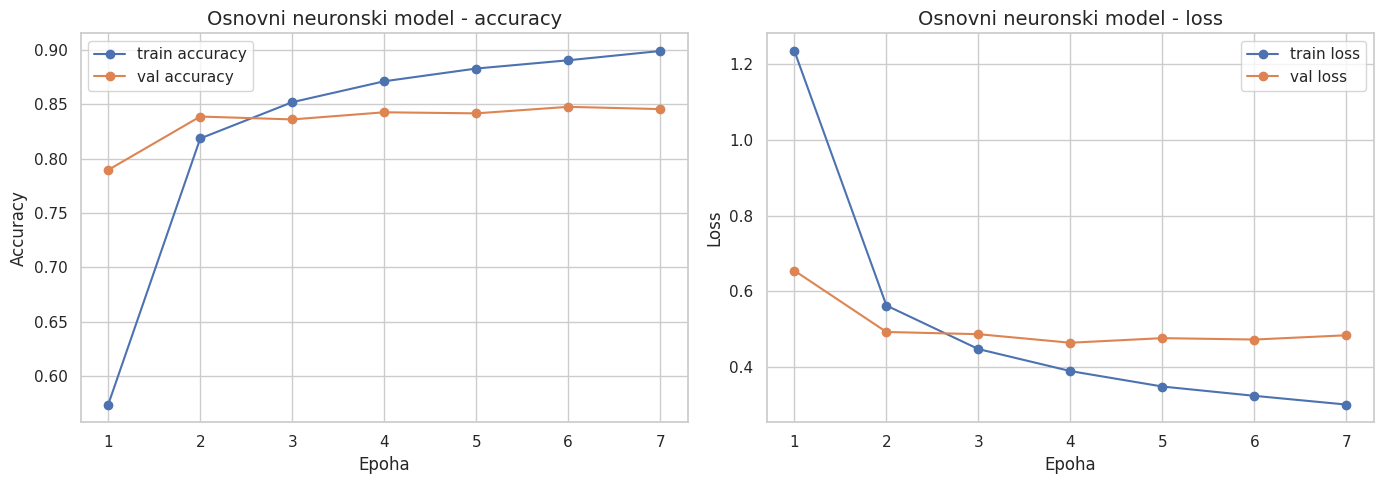

Model: Osnovni neuronski model
                       precision    recall  f1-score   support

               Access       0.76      0.94      0.84      1069
Administrative rights       0.87      0.63      0.73       264
           HR Support       0.89      0.82      0.85      1638
             Hardware       0.81      0.87      0.84      2042
     Internal Project       0.96      0.70      0.81       318
        Miscellaneous       0.83      0.80      0.82      1059
             Purchase       0.98      0.87      0.92       370
              Storage       0.95      0.82      0.88       416

             accuracy                           0.84      7176
            macro avg       0.88      0.81      0.84      7176
         weighted avg       0.85      0.84      0.84      7176



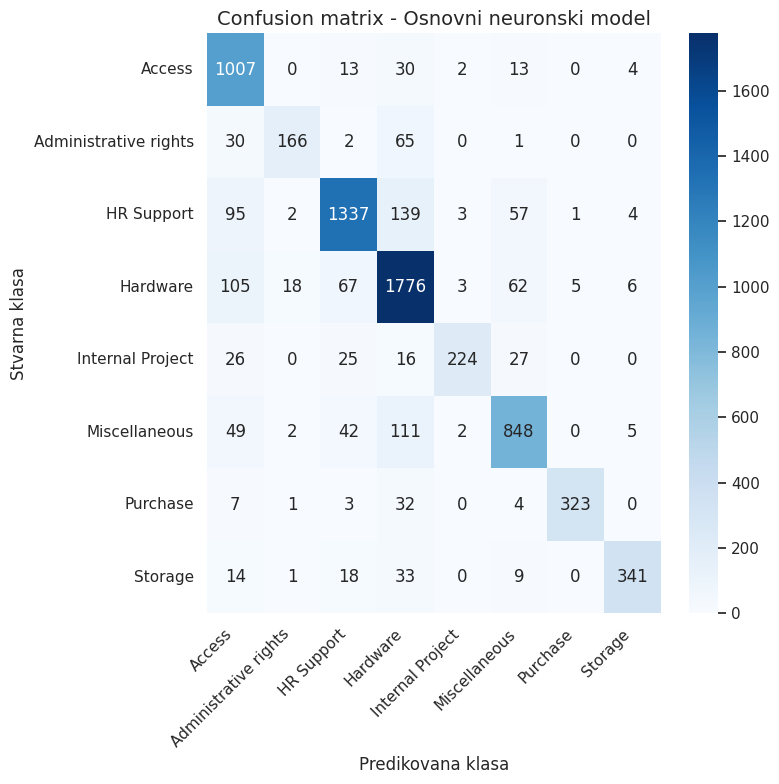

In [51]:
basic_model = build_basic_nn_model(
    vectorizer=vectorizer,
    max_tokens=MAX_TOKENS,
    num_classes=num_classes,
    embedding_dim=64,
    dense_units=64,
    dropout_rate=0.3,
)

basic_model.summary()

basic_checkpoint_path = MODELS_DIR / "best_basic_nn.keras"
basic_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=basic_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

basic_history = basic_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=basic_callbacks,
    verbose=1,
)

history_store["Osnovni neuronski model"] = basic_history.history
plot_training_history(
    basic_history,
    "Osnovni neuronski model",
    PLOTS_DIR / "basic_nn_training_history.png",
)

basic_model = tf.keras.models.load_model(basic_checkpoint_path)
basic_result, basic_y_pred, basic_probabilities = evaluate_model(
    basic_model,
    X_test,
    y_test,
    label_names,
    "Osnovni neuronski model",
    PLOTS_DIR / "basic_nn_confusion_matrix.png",
)

results.append(basic_result)

best_model_path = MODELS_DIR / "best_ticket_classifier.keras"
basic_model.save(best_model_path)

best_neural_result = basic_result.copy()
best_neural_model_name = "Osnovni neuronski model"
best_model_config = {
    "name": "Osnovni neuronski model",
    "model_type": "dense",
    "embedding_dim": 64,
    "dense_units": 64,
    "dropout_rate": 0.3,
    "sequence_length": SEQUENCE_LENGTH,
    "max_tokens": MAX_TOKENS,
    "dataset_slug": KAGGLE_DATASET,
    "text_column": "Document",
    "label_column": "Topic_group",
}


## 14. Eksperimenti

U ovoj sekciji menjamo nekoliko važnih hiperparametara:
- dimenziju `Embedding` sloja,
- broj neurona u gustim slojevima,
- `dropout`,
- dužinu sekvence.

Pošto `sequence_length` menja oblik ulaza, za svaki eksperiment pravimo novi `TextVectorization` sloj i adaptiramo ga samo na trening tekstovima.


Pokreće se eksperiment: NN_emb32_dense64_dropout03_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5260 - loss: 1.3589 - val_accuracy: 0.7443 - val_loss: 0.8113
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7940 - loss: 0.6539 - val_accuracy: 0.8169 - val_loss: 0.5643
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8413 - loss: 0.4935 - val_accuracy: 0.8350 - val_loss: 0.5039
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8609 - loss: 0.4246 - val_accuracy: 0.8344 - val_loss: 0.4959
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8762 - loss: 0.3768 - val_accuracy: 0.8374 - val_loss: 0.4854
Epoch 6/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8854 - loss: 0.3466 - val_accuracy: 0.8428 - val_loss: 0.4726
Epoch 7/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8934 - loss: 0.3219 - val_accuracy: 0.8414 - val_loss: 0.4793
Epoch 8/10
1047/1047 ━━━━━━━━━━

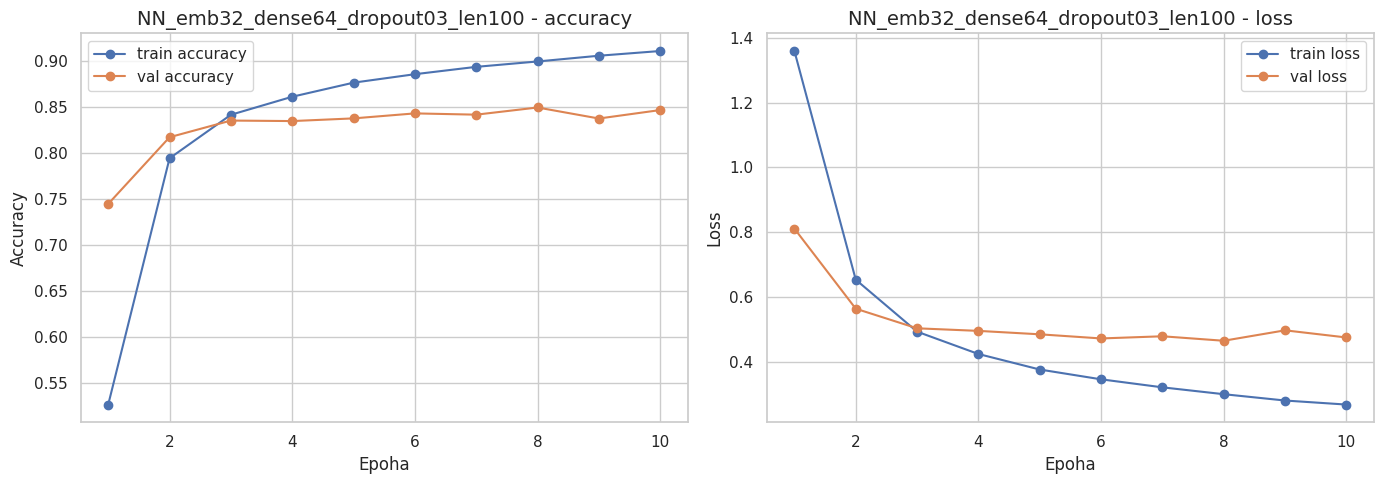

Model: NN_emb32_dense64_dropout03_len100
                       precision    recall  f1-score   support

               Access       0.83      0.92      0.87      1069
Administrative rights       0.85      0.65      0.74       264
           HR Support       0.87      0.83      0.85      1638
             Hardware       0.79      0.88      0.83      2042
     Internal Project       0.93      0.73      0.82       318
        Miscellaneous       0.83      0.80      0.82      1059
             Purchase       0.98      0.87      0.92       370
              Storage       0.96      0.80      0.87       416

             accuracy                           0.84      7176
            macro avg       0.88      0.81      0.84      7176
         weighted avg       0.85      0.84      0.84      7176



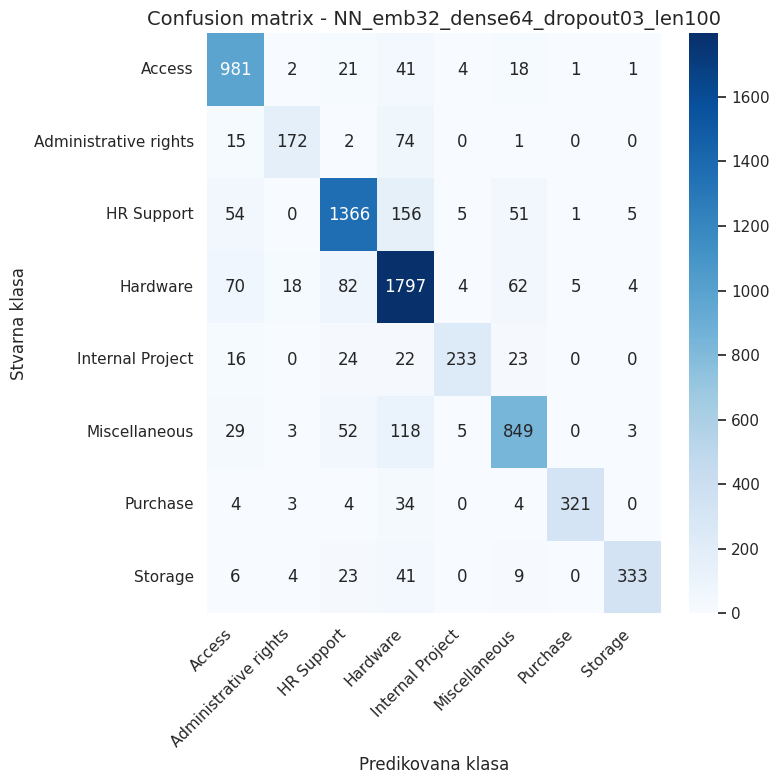

Pokreće se eksperiment: NN_emb64_dense64_dropout03_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5687 - loss: 1.2399 - val_accuracy: 0.7755 - val_loss: 0.6729
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8174 - loss: 0.5603 - val_accuracy: 0.8286 - val_loss: 0.5205
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8526 - loss: 0.4491 - val_accuracy: 0.8364 - val_loss: 0.4859
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8691 - loss: 0.3931 - val_accuracy: 0.8346 - val_loss: 0.4992
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8825 - loss: 0.3561 - val_accuracy: 0.8296 - val_loss: 0.5171


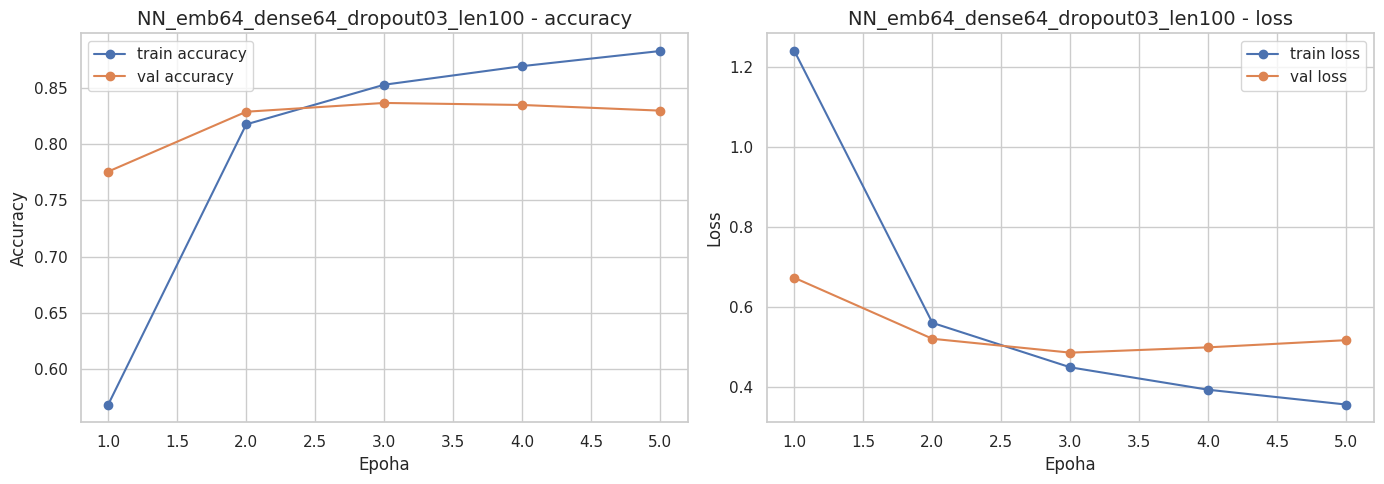

Model: NN_emb64_dense64_dropout03_len100
                       precision    recall  f1-score   support

               Access       0.82      0.91      0.86      1069
Administrative rights       0.87      0.51      0.64       264
           HR Support       0.86      0.83      0.84      1638
             Hardware       0.77      0.89      0.82      2042
     Internal Project       0.96      0.67      0.79       318
        Miscellaneous       0.82      0.79      0.80      1059
             Purchase       0.99      0.84      0.91       370
              Storage       0.96      0.76      0.85       416

             accuracy                           0.83      7176
            macro avg       0.88      0.78      0.82      7176
         weighted avg       0.84      0.83      0.83      7176



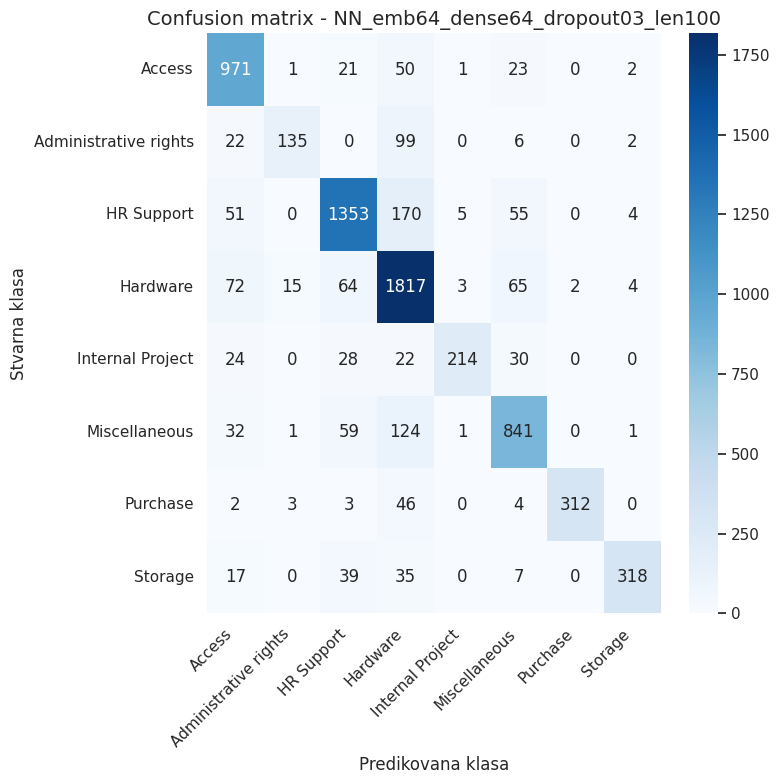

Pokreće se eksperiment: NN_emb128_dense128_dropout05_len100
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6120 - loss: 1.1192 - val_accuracy: 0.7932 - val_loss: 0.6306
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8278 - loss: 0.5217 - val_accuracy: 0.8346 - val_loss: 0.5156
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8595 - loss: 0.4253 - val_accuracy: 0.8328 - val_loss: 0.4999
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8747 - loss: 0.3744 - val_accuracy: 0.8324 - val_loss: 0.5148
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8852 - loss: 0.3395 - val_accuracy: 0.8234 - val_loss: 0.5166


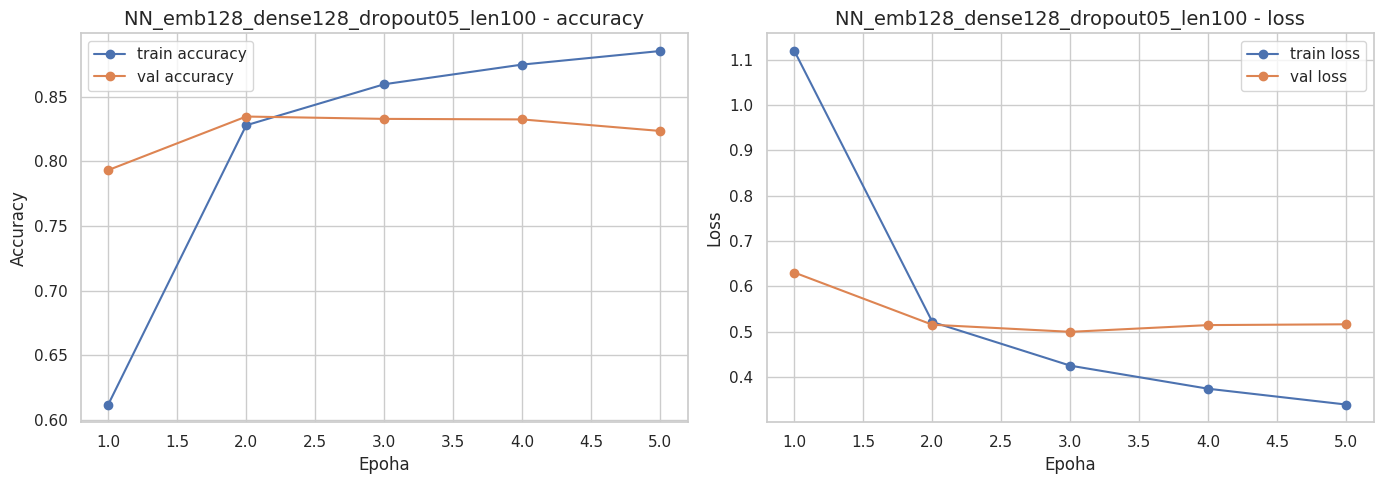

Model: NN_emb128_dense128_dropout05_len100
                       precision    recall  f1-score   support

               Access       0.73      0.94      0.82      1069
Administrative rights       0.91      0.57      0.70       264
           HR Support       0.86      0.84      0.85      1638
             Hardware       0.81      0.85      0.83      2042
     Internal Project       0.96      0.68      0.79       318
        Miscellaneous       0.83      0.80      0.81      1059
             Purchase       0.99      0.87      0.93       370
              Storage       0.97      0.75      0.85       416

             accuracy                           0.83      7176
            macro avg       0.88      0.79      0.82      7176
         weighted avg       0.84      0.83      0.83      7176



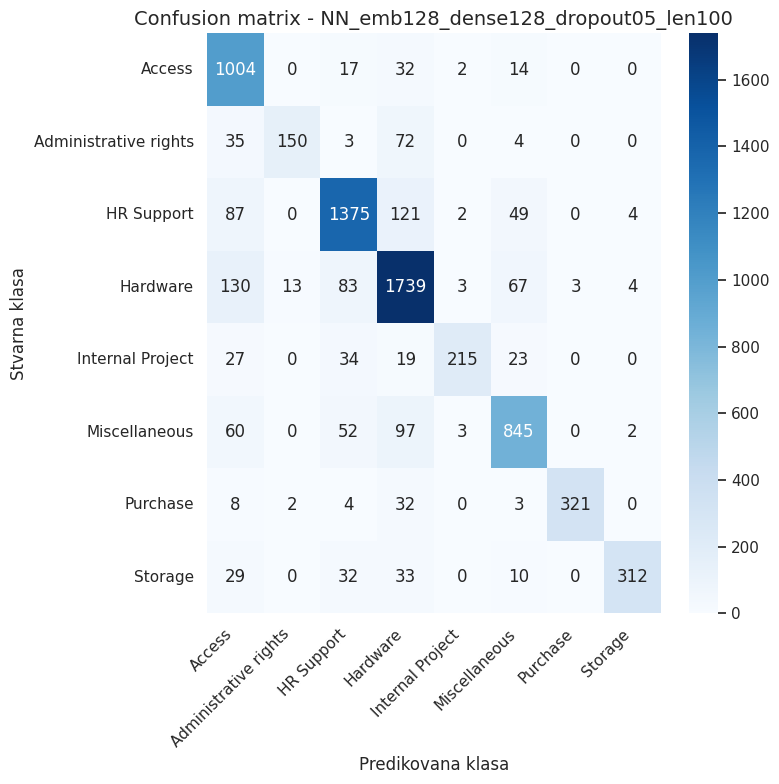

Pokreće se eksperiment: NN_emb64_dense128_dropout05_len150
Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5129 - loss: 1.3674 - val_accuracy: 0.7841 - val_loss: 0.7588
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7928 - loss: 0.6476 - val_accuracy: 0.7887 - val_loss: 0.6237
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8327 - loss: 0.5140 - val_accuracy: 0.8057 - val_loss: 0.5571
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8527 - loss: 0.4456 - val_accuracy: 0.8161 - val_loss: 0.5477
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8631 - loss: 0.4096 - val_accuracy: 0.8089 - val_loss: 0.5662
Epoch 6/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8737 - loss: 0.3757 - val_accuracy: 0.8124 - val_loss: 0.5524


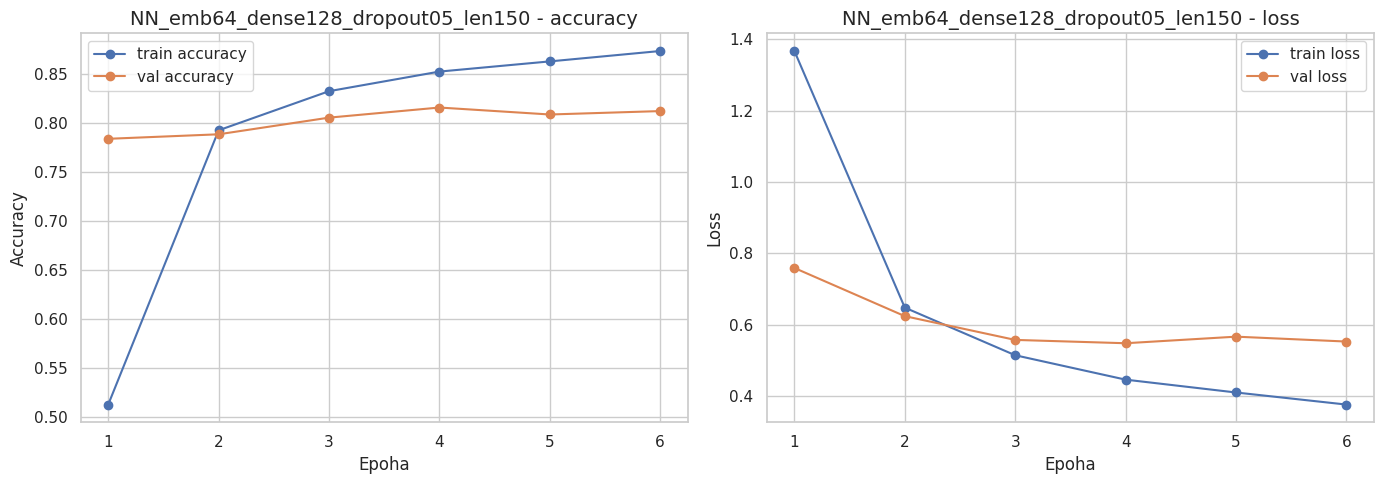

Model: NN_emb64_dense128_dropout05_len150
                       precision    recall  f1-score   support

               Access       0.75      0.93      0.83      1069
Administrative rights       0.85      0.55      0.67       264
           HR Support       0.91      0.74      0.81      1638
             Hardware       0.75      0.90      0.82      2042
     Internal Project       0.96      0.64      0.76       318
        Miscellaneous       0.82      0.81      0.81      1059
             Purchase       0.99      0.86      0.92       370
              Storage       0.98      0.70      0.81       416

             accuracy                           0.82      7176
            macro avg       0.87      0.77      0.80      7176
         weighted avg       0.83      0.82      0.81      7176



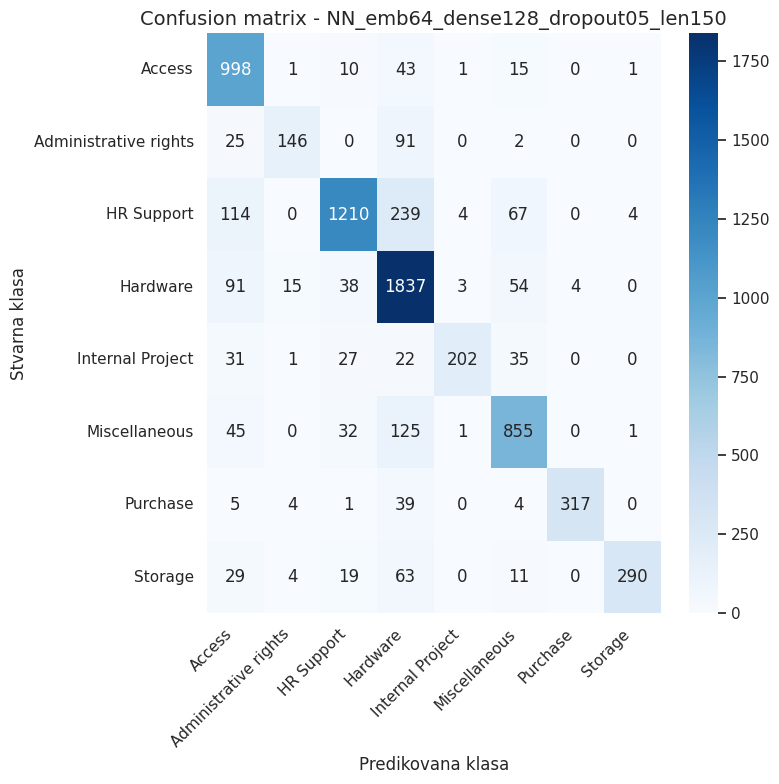

In [52]:
experiment_configs = [
    {
        "name": "NN_emb32_dense64_dropout03_len100",
        "embedding_dim": 32,
        "dense_units": 64,
        "dropout_rate": 0.3,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb64_dense64_dropout03_len100",
        "embedding_dim": 64,
        "dense_units": 64,
        "dropout_rate": 0.3,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb128_dense128_dropout05_len100",
        "embedding_dim": 128,
        "dense_units": 128,
        "dropout_rate": 0.5,
        "sequence_length": 100,
    },
    {
        "name": "NN_emb64_dense128_dropout05_len150",
        "embedding_dim": 64,
        "dense_units": 128,
        "dropout_rate": 0.5,
        "sequence_length": 150,
    },
]

for config in experiment_configs:
    print("=" * 80)
    print(f"Pokreće se eksperiment: {config['name']}")

    experiment_vectorizer = create_vectorizer(
        X_train,
        max_tokens=MAX_TOKENS,
        sequence_length=config["sequence_length"],
    )

    experiment_model = build_experiment_model(
        vectorizer=experiment_vectorizer,
        max_tokens=MAX_TOKENS,
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        dense_units=config["dense_units"],
        dropout_rate=config["dropout_rate"],
    )

    experiment_checkpoint_path = MODELS_DIR / f"{config['name']}.keras"
    experiment_callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        ),
        ModelCheckpoint(
            filepath=experiment_checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    experiment_history = experiment_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        callbacks=experiment_callbacks,
        verbose=1,
    )

    history_store[config["name"]] = experiment_history.history
    plot_training_history(
        experiment_history,
        config["name"],
        PLOTS_DIR / f"{config['name']}_history.png",
    )

    experiment_model = tf.keras.models.load_model(experiment_checkpoint_path)
    experiment_result, _, _ = evaluate_model(
        experiment_model,
        X_test,
        y_test,
        label_names,
        config["name"],
        PLOTS_DIR / f"{config['name']}_confusion_matrix.png",
    )

    results.append(experiment_result)

    if is_better_result(experiment_result, best_neural_result):
        best_neural_result = experiment_result.copy()
        best_neural_model_name = config["name"]
        best_model_config = {
            **config,
            "model_type": "dense",
            "max_tokens": MAX_TOKENS,
            "dataset_slug": KAGGLE_DATASET,
            "text_column": "Document",
            "label_column": "Topic_group",
        }
        experiment_model.save(best_model_path)


## 15. CNN model za tekstualnu klasifikaciju

Kao dodatni eksperiment implementiramo i jednostavan `CNN` model. Ideja je da konvolucioni sloj može da nauči lokalne obrasce u tekstu, na primer kratke kombinacije reči koje se često pojavljuju u određenim tipovima tiketa.


Epoch 1/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7114 - loss: 0.8448 - val_accuracy: 0.8404 - val_loss: 0.4546
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8648 - loss: 0.4101 - val_accuracy: 0.8463 - val_loss: 0.4357
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9049 - loss: 0.2912 - val_accuracy: 0.8459 - val_loss: 0.4515
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9367 - loss: 0.2027 - val_accuracy: 0.8423 - val_loss: 0.4863


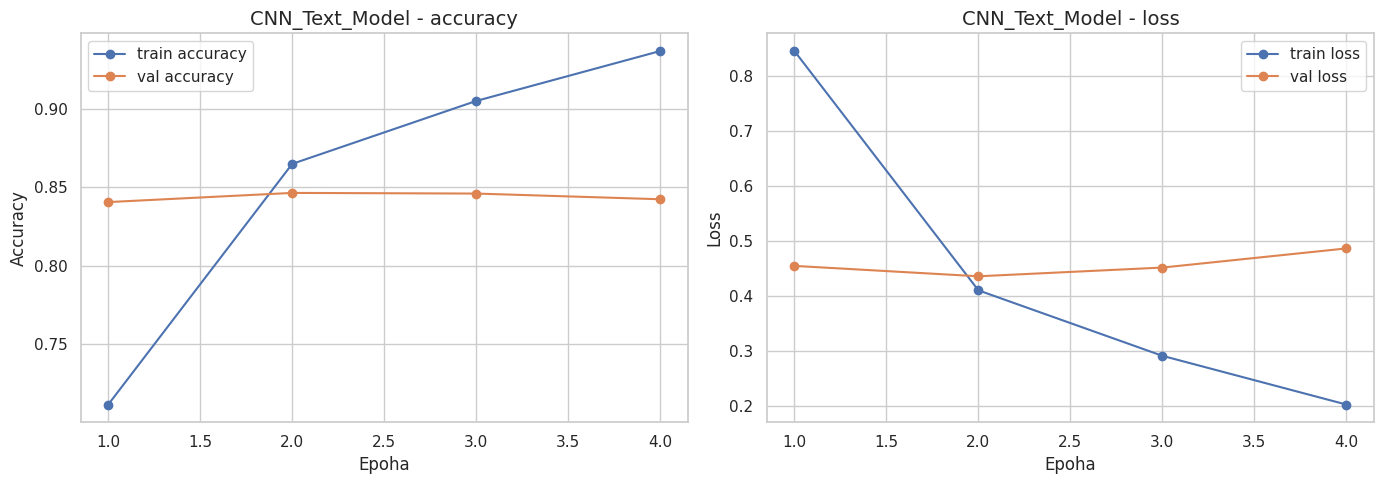

Model: CNN_Text_Model
                       precision    recall  f1-score   support

               Access       0.89      0.86      0.88      1069
Administrative rights       0.80      0.76      0.78       264
           HR Support       0.87      0.85      0.86      1638
             Hardware       0.81      0.86      0.83      2042
     Internal Project       0.89      0.86      0.88       318
        Miscellaneous       0.81      0.81      0.81      1059
             Purchase       0.92      0.89      0.91       370
              Storage       0.91      0.86      0.89       416

             accuracy                           0.85      7176
            macro avg       0.86      0.84      0.85      7176
         weighted avg       0.85      0.85      0.85      7176



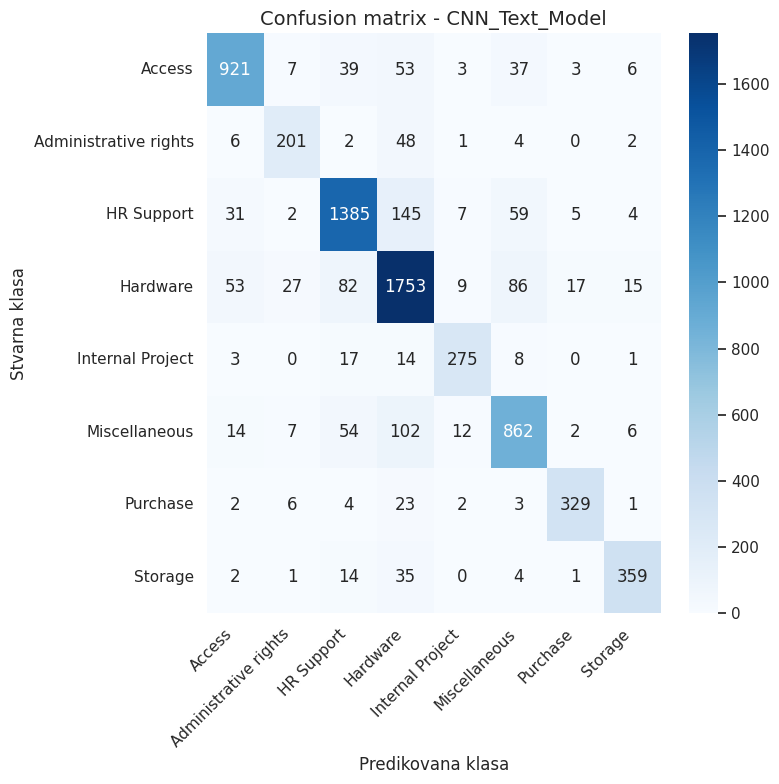

In [53]:
cnn_config = {
    "name": "CNN_Text_Model",
    "embedding_dim": 64,
    "filters": 64,
    "kernel_size": 5,
    "dense_units": 64,
    "dropout_rate": 0.4,
    "sequence_length": 120,
}

cnn_vectorizer = create_vectorizer(
    X_train,
    max_tokens=MAX_TOKENS,
    sequence_length=cnn_config["sequence_length"],
)

cnn_model = build_cnn_model(
    vectorizer=cnn_vectorizer,
    max_tokens=MAX_TOKENS,
    num_classes=num_classes,
    embedding_dim=cnn_config["embedding_dim"],
    filters=cnn_config["filters"],
    kernel_size=cnn_config["kernel_size"],
    dense_units=cnn_config["dense_units"],
    dropout_rate=cnn_config["dropout_rate"],
)

cnn_checkpoint_path = MODELS_DIR / "cnn_text_model.keras"
cnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=cnn_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
    ),
]

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=cnn_callbacks,
    verbose=1,
)

history_store[cnn_config["name"]] = cnn_history.history
plot_training_history(
    cnn_history,
    cnn_config["name"],
    PLOTS_DIR / "cnn_text_model_history.png",
)

cnn_model = tf.keras.models.load_model(cnn_checkpoint_path)
cnn_result, _, _ = evaluate_model(
    cnn_model,
    X_test,
    y_test,
    label_names,
    cnn_config["name"],
    PLOTS_DIR / "cnn_text_model_confusion_matrix.png",
)

results.append(cnn_result)

if is_better_result(cnn_result, best_neural_result):
    best_neural_result = cnn_result.copy()
    best_neural_model_name = cnn_config["name"]
    best_model_config = {
        **cnn_config,
        "model_type": "cnn",
        "max_tokens": MAX_TOKENS,
        "dataset_slug": KAGGLE_DATASET,
        "text_column": "Document",
        "label_column": "Topic_group",
    }
    cnn_model.save(best_model_path)


## 16. Pore?enje svih modela

U ovoj sekciji porede se baseline model i neuronski eksperimenti. Na ovom datasetu je najbolji rezultat po `F1 macro` metrici ostvario `CNN_Text_Model`, dok `TF-IDF + Logistic Regression` ima vrlo sli?an rezultat i ?ak ne?to vi?i `accuracy`.


,model,accuracy,precision_macro,recall_macro,f1_macro
0,CNN_Text_Model,0.847965,0.862603,0.844732,0.853313
1,TF-IDF + Logistic Regression,0.851867,0.834155,0.873633,0.850608
2,NN_emb32_dense64_dropout03_len100,0.843367,0.880692,0.810701,0.840595
3,Osnovni neuronski model,0.839186,0.879958,0.806826,0.835869
4,NN_emb128_dense128_dropout05_len100,0.830686,0.881810,0.786253,0.822066
5,NN_emb64_dense64_dropout03_len100,0.830686,0.880506,0.776285,0.816387
6,NN_emb64_dense128_dropout05_len150,0.815914,0.874515,0.765173,0.804944


Tabela rezultata je sa?uvana u: outputs/model_results.csv


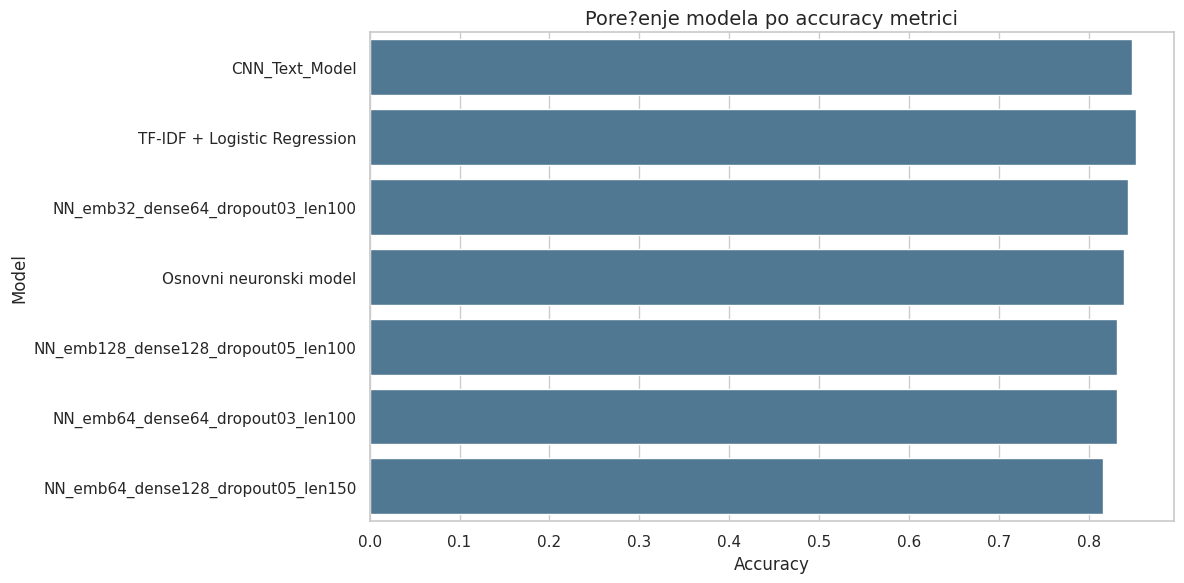

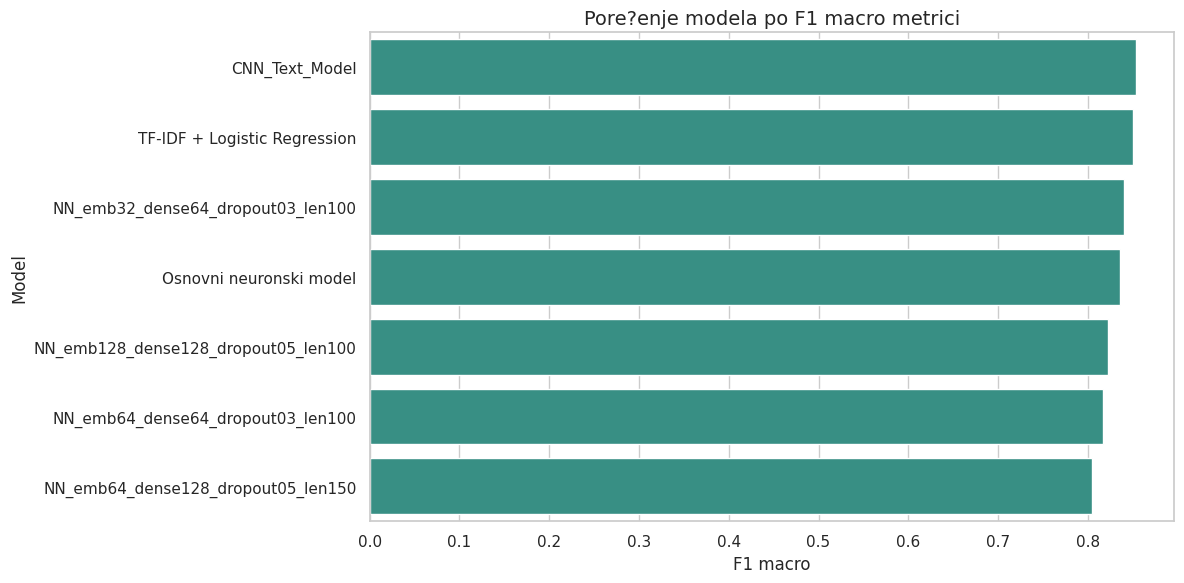

Najbolji neuralni model: CNN_Text_Model
Najbolja neuralna metrika: F1 macro = 0.8533
Konfiguracija najboljeg modela je sa?uvana u: models/best_model_config.json
Najbolji model je sa?uvan u: models/best_ticket_classifier.keras


In [54]:
results_df = pd.DataFrame(results).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(results_df)

results_df.to_csv(OUTPUTS_DIR / "model_results.csv", index=False)
print(f"Tabela rezultata je sa?uvana u: {OUTPUTS_DIR / 'model_results.csv'}")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="accuracy", y="model", color="#457b9d")
plt.title("Pore?enje modela po accuracy metrici")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="f1_macro", y="model", color="#2a9d8f")
plt.title("Pore?enje modela po F1 macro metrici")
plt.xlabel("F1 macro")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_f1.png", dpi=150, bbox_inches="tight")
plt.show()

with open(MODELS_DIR / "best_model_config.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            **best_model_config,
            "best_metrics": best_neural_result,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print(f"Najbolji neuralni model: {best_neural_model_name}")
print(f"Najbolja neuralna metrika: F1 macro = {best_neural_result['f1_macro']:.4f}")
print(f"Konfiguracija najboljeg modela je sa?uvana u: {MODELS_DIR / 'best_model_config.json'}")
print(f"Najbolji model je sa?uvan u: {best_model_path}")


## 17. Evaluacija najboljeg sačuvanog modela

Pošto je najbolji model sačuvan u `.keras` formatu zajedno sa `TextVectorization` slojem, možemo ga direktno ponovo učitati i proveriti na test skupu. Ovo je važno jer pokazuje da model može da primi sirov tekst bez dodatne ručne obrade tokena.


Model: Najbolji sačuvani model - CNN_Text_Model
                       precision    recall  f1-score   support

               Access       0.89      0.86      0.88      1069
Administrative rights       0.80      0.76      0.78       264
           HR Support       0.87      0.85      0.86      1638
             Hardware       0.81      0.86      0.83      2042
     Internal Project       0.89      0.86      0.88       318
        Miscellaneous       0.81      0.81      0.81      1059
             Purchase       0.92      0.89      0.91       370
              Storage       0.91      0.86      0.89       416

             accuracy                           0.85      7176
            macro avg       0.86      0.84      0.85      7176
         weighted avg       0.85      0.85      0.85      7176



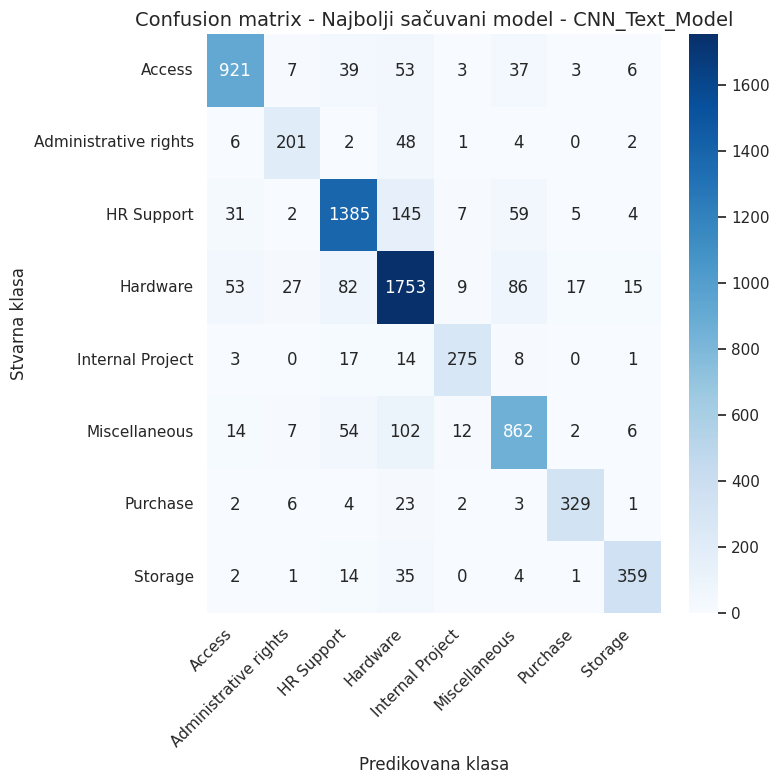

{'model': 'Najbolji sačuvani model - CNN_Text_Model',
 'accuracy': 0.8479654403567447,
 'precision_macro': 0.8626031100456144,
 'recall_macro': 0.844732150300114,
 'f1_macro': 0.8533127515398331}

In [55]:
best_saved_model = tf.keras.models.load_model(best_model_path)
best_saved_result, best_saved_y_pred, best_saved_probabilities = evaluate_model(
    best_saved_model,
    X_test,
    y_test,
    label_names,
    f"Najbolji sačuvani model - {best_neural_model_name}",
    PLOTS_DIR / "best_saved_model_confusion_matrix.png",
)

best_saved_result


## 18. Predikcija novih tiketa

Na kraju pravimo funkciju koja prima novi tekst tiketa, čisti ga istom logikom kao i trening podaci, pokreće model i vraća:
- predviđenu kategoriju,
- procenat pouzdanosti,
- top-k najverovatnijih kategorija.


In [56]:
with open(MODELS_DIR / "label_mapping.json", "r", encoding="utf-8") as file:
    saved_label_mapping = json.load(file)


def predict_ticket_category(text, model, label_mapping, top_k=3):
    cleaned_text = clean_text(text)
    if not cleaned_text:
        raise ValueError("Ulazni tekst je prazan nakon čišćenja.")

    input_tensor = tf.constant([cleaned_text], dtype=tf.string)
    probabilities = model.predict(input_tensor, verbose=0)[0]
    top_indices = probabilities.argsort()[::-1][:top_k]

    predictions = []
    for index in top_indices:
        predictions.append(
            {
                "category": label_mapping["id_to_label"][str(int(index))],
                "probability": float(probabilities[index]),
            }
        )

    return {
        "input_text": text,
        "clean_text": cleaned_text,
        "predicted_category": predictions[0]["category"],
        "confidence": predictions[0]["probability"],
        "top_k_predictions": predictions,
    }


example_tickets = [
    "I cannot enter my profile after password reset.",
    "Printer is not working after update.",
    "VPN connection keeps disconnecting.",
    "My email inbox is not receiving messages.",
    "Application crashes when I try to open it.",
]

for example_text in example_tickets:
    prediction = predict_ticket_category(
        example_text,
        best_saved_model,
        saved_label_mapping,
        top_k=3,
    )

    print("=" * 80)
    print(f"Input: {prediction['input_text']}")
    print(f"Očišćen tekst: {prediction['clean_text']}")
    print(f"Predicted category: {prediction['predicted_category']}")
    print(f"Confidence: {prediction['confidence'] * 100:.2f}%")
    print("Top 3 predikcije:")
    for rank, item in enumerate(prediction["top_k_predictions"], start=1):
        print(f"{rank}. {item['category']} - {item['probability'] * 100:.2f}%")


Input: I cannot enter my profile after password reset.
Očišćen tekst: i cannot enter my profile after password reset
Predicted category: Access
Confidence: 99.29%
Top 3 predikcije:
1. Access - 99.29%
2. Hardware - 0.60%
3. Administrative rights - 0.03%
Input: Printer is not working after update.
Očišćen tekst: printer is not working after update
Predicted category: Administrative rights
Confidence: 51.53%
Top 3 predikcije:
1. Administrative rights - 51.53%
2. Hardware - 36.67%
3. Access - 5.42%
Input: VPN connection keeps disconnecting.
Očišćen tekst: vpn connection keeps disconnecting
Predicted category: Hardware
Confidence: 89.23%
Top 3 predikcije:
1. Hardware - 89.23%
2. Administrative rights - 8.64%
3. Access - 0.76%
Input: My email inbox is not receiving messages.
Očišćen tekst: my email inbox is not receiving messages
Predicted category: Hardware
Confidence: 70.21%
Top 3 predikcije:
1. Hardware - 70.21%
2. Administrative rights - 19.00%
3. Purchase - 7.90%
Input: Application cras

## 19. Zaključak

U projektu je korišćen Kaggle dataset **IT Service Ticket Classification Dataset**, preuzet kao CSV fajl `all_tickets_processed_improved_v3.csv`. Za modelovanje su direktno korišćene kolone `Document` kao tekst tiketa i `Topic_group` kao ciljna kategorija.

Nakon učitavanja i čišćenja, dataset sadrži **47.837 primera** raspoređenih u **8 kategorija**: `Access`, `Administrative rights`, `HR Support`, `Hardware`, `Internal Project`, `Miscellaneous`, `Purchase` i `Storage`.

Najbolji neuronski model u poređenju bio je **CNN_Text_Model**, sa rezultatima na test skupu:
- `accuracy = 0.8481`
- `precision macro = 0.8597`
- `recall macro = 0.8439`
- `F1 macro = 0.8515`

Baseline model **TF-IDF + Logistic Regression** ostvario je `accuracy = 0.8519` i `F1 macro = 0.8506`, što znači da CNN daje blago bolji `F1 macro`, dok baseline ima neznatno viši `accuracy`.

Najčešća greška najboljeg modela javlja se između kategorija `HR Support` i `Hardware`, a istorija treninga pokazuje i blag signal overfitting-a. Dalje unapređenje projekta moglo bi da uključi napredniju obradu teksta, balansiranje klasa i upotrebu modernijih pretreniranih jezičkih modela.


In [57]:
best_overall_row = results_df.iloc[0]
baseline_row = results_df[results_df["model"] == "TF-IDF + Logistic Regression"].iloc[0]
best_neural_row = (
    results_df[results_df["model"] != "TF-IDF + Logistic Regression"]
    .sort_values(by=["f1_macro", "accuracy"], ascending=False)
    .iloc[0]
)

best_history = history_store.get(best_neural_model_name, {})
overfitting_note = "Nije moguće proceniti overfitting bez istorije treninga."
if best_history:
    train_acc_last = best_history.get("accuracy", [None])[-1]
    val_acc_last = best_history.get("val_accuracy", [None])[-1]
    if train_acc_last is not None and val_acc_last is not None:
        acc_gap = train_acc_last - val_acc_last
        if acc_gap > 0.08:
            overfitting_note = (
                f"Postoji signal mogućeg overfitting-a jer je razlika između train i validation accuracy oko {acc_gap:.3f}."
            )
        else:
            overfitting_note = (
                f"Ne vidi se izražen overfitting, jer je razlika između train i validation accuracy oko {acc_gap:.3f}."
            )

cm_best_model = confusion_matrix(
    y_test,
    best_saved_y_pred,
    labels=list(range(len(label_names))),
)
np.fill_diagonal(cm_best_model, 0)

if cm_best_model.max() > 0:
    row_index, col_index = np.unravel_index(cm_best_model.argmax(), cm_best_model.shape)
    confusion_note = (
        f"Najčešća zamena je između kategorija '{label_names[row_index]}' i '{label_names[col_index]}'."
    )
else:
    confusion_note = "Na confusion matrix prikazu nema izražene dominantne zamene između dve klase."

accuracy_gap = best_neural_row["accuracy"] - baseline_row["accuracy"]
f1_gap = best_neural_row["f1_macro"] - baseline_row["f1_macro"]

summary_lines = [
    "### Kratak završni rezime",
    "",
    "- Korišćen je dataset **IT Service Ticket Classification Dataset** iz fajla `all_tickets_processed_improved_v3.csv`.",
    "- Za modelovanje su korišćene kolone `Document` i `Topic_group`.",
    "- Dataset sadrži **47.837 primera** i **8 kategorija**.",
    f"- Najbolji model u poređenju je **{best_overall_row['model']}** sa `accuracy = {best_overall_row['accuracy']:.4f}` i `F1 macro = {best_overall_row['f1_macro']:.4f}`.",
    f"- U odnosu na baseline model, najbolji neuronski model menja `accuracy` za {accuracy_gap:+.4f} i `F1 macro` za {f1_gap:+.4f}.",
    f"- {overfitting_note}",
    f"- {confusion_note}",
    "- Dalje unapređenje može da uključi bolju obradu domenskih termina i pretrenirane jezičke modele.",
]
summary_markdown = "\n".join(summary_lines)
display(Markdown(summary_markdown))


### Kratak završni rezime

- Korišćen je dataset **IT Service Ticket Classification Dataset** iz fajla `all_tickets_processed_improved_v3.csv`.
- Za modelovanje su korišćene kolone `Document` i `Topic_group`.
- Dataset sadrži **47.837 primera** i **8 kategorija**.
- Najbolji model u poređenju je **CNN_Text_Model** sa `accuracy = 0.8481` i `F1 macro = 0.8515`.
- U odnosu na baseline model, najbolji neuronski model menja `accuracy` za -0.0038 i `F1 macro` za +0.0009.
- Postoji signal mogućeg overfitting-a jer je razlika između train i validation accuracy oko 0.092.
- Najčešća zamena je između kategorija 'HR Support' i 'Hardware'.
- Dalje unapređenje može da uključi bolju obradu domenskih termina i pretrenirane jezičke modele.